In [2]:
# Standard libraries
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib.colors as mcolors
from mpl_toolkits.axes_grid1 import make_axes_locatable
import sys, os
# Project Path Setup
from setup_project_path import check_and_add_project_path  # Script to check and add project path
check_and_add_project_path()


# Import Custom Modules
from src.utils.module_utils.all_custom_modules import cf, DataInterp, Hdf5Kernel, fit_logarithmic, log_func # Consolidated custom modules import
import src.utils.common_funcs as cf



Project path successfully added.


In [58]:

filename_AAA_sc = f'../data/paper/paper_AAA_semicircle_smooth_0.8_sharpness20.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_rank_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc = data_h5_AAA_sc["N_max"]
betas_sc = data_h5_AAA_sc["beta"]
delta_t_vals_sc = data_h5_AAA_sc["delta_t"]
tol_vals_sc = data_h5_AAA_sc["tol"]
Z_vals_sc = data_h5_AAA_sc["Z"]
F_vals_sc = data_h5_AAA_sc["F_particle"]


t_data = np.array([np.max(N_maxs_sc[:,tau,:] * delta_t_vals_sc[:,tau,:]) for tau in range (kernel_dims_AAA_sc[1])])

print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")
#print("errors AAA ", errors_AAA_sc)
#print("nbr_poles_upper ", nbr_poles_upper_sc)




def get_idx(tol, tau, beta):
    return tol * kernel_dims_AAA_sc[1] *  kernel_dims_AAA_sc[2] + tau * kernel_dims_AAA_sc[2] + beta

# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-','--', '-.', ':']
    return cycle(predefined_linestyles[:n])



Dimensions of data arrays: [100  15   2].


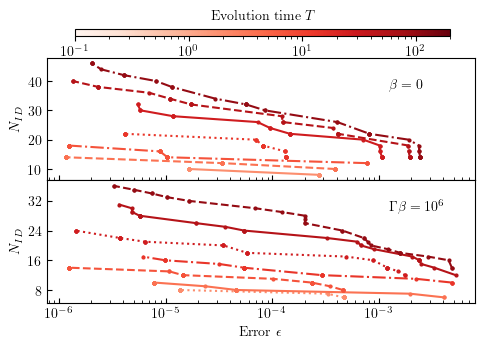

In [59]:
# Set global fontsize using rcParams
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})
from itertools import cycle
cmap_reds = plt.get_cmap("Reds")
norm_times = mcolors.LogNorm(vmin=0.1*np.min(t_data[t_data > 0]), vmax=2*np.max(t_data))
fig, axs = plt.subplots(2, 1, figsize=(5, 3.5), sharex=True)

# Collect handles and labels for the legend
handles_AAA = []
labels_AAA = []

linestyles = generate_linestyles_cycler(kernel_dims_AAA_sc[1])
linecycler = cycle(linestyles)

for b in range(kernel_dims_AAA_sc[2]):
    for tau in np.arange(kernel_dims_AAA_sc[1]-1,0,-2)[::-1]:
        linestyle = next(linecycler)
        err_AAA_sc = []
        nbr_poles_sc = []
       
        for tol_iter in range(len(tol_vals_sc[:, tau, b])):
            err_AAA_sc.append(errors_AAA_sc[tol_iter, tau, b])
            nbr_poles_sc.append(AAA_ID_rank_particle[tol_iter, tau, b] + AAA_ID_rank_holes[tol_iter, tau, b])

    
        mask = np.array(err_AAA_sc) > 1.1e-6
       
        line_AAA, = axs[b].plot(np.array(err_AAA_sc)[mask], np.array(nbr_poles_sc)[mask], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])), label=r'$t = {}$'.format(round(t_data[tau], 2)))
     

        if line_AAA.get_label() not in labels_AAA:
            handles_AAA.append(line_AAA)
            labels_AAA.append(line_AAA.get_label())
      

    axs[b].set_xlabel("Error "+ r"$\epsilon$")
    axs[b].set_ylabel(r"$N_{ID}$")
    axs[b].set_xscale("log")
    

#for text inset, choose background color white
axs[0].text(0.8, 0.75, r"$\beta = 0$", transform=axs[0].transAxes, backgroundcolor='white')
axs[1].text(0.8, 0.75, r"$  \Gamma\beta = 10^6$", transform=axs[1].transAxes, backgroundcolor='white')

# Add a single legend above the entire figure
from matplotlib.legend import Legend

# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

# Create custom legends
#legend = Legend(fig, handles_AAA, labels_AAA, loc='upper center', ncol=len(t_data), fontsize='small', title="AAA (Red Curves)")
# Add the legends manually
#fig.add_artist(legend)
#legend.set_bbox_to_anchor((0.5, .95))


# Add a colorbar for the reds above the figure
cax_reds = fig.add_axes([0.17, 0.92, 0.75, 0.02])
sm_reds = cm.ScalarMappable(cmap=cmap_reds, norm=norm_times)
sm_reds.set_array([])
cbar_reds = fig.colorbar(sm_reds, cax=cax_reds, orientation='horizontal')
cbar_reds.set_label("Evolution time " + r'$T$', labelpad=-35, fontsize='medium')

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')
    # Ensure y-axis ticks are integers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))

#limit the number of bins in the y axis to 5
for ax in axs.flat:
    ax.yaxis.set_major_locator(plt.MaxNLocator(5))

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

#save figure as pdf
fig.savefig("../plots/paper/AAA_semicircle_smoothening20.pdf", bbox_inches='tight')





AAA 0.3256947497335506 4.47433173684618
AAA 0.3791351516874689 3.9495528694894344
global_min 0.3256947497335506
global_max 4.47433173684618
global_min 0.1
global_max 10.0


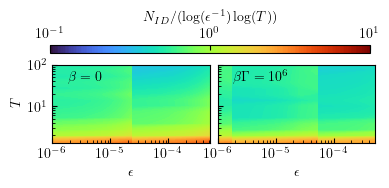

In [45]:
fig, axs = plt.subplots(1,2, figsize=(4, 1.7), sharex=True, sharey=True)


global_min = float('inf')
global_max = float('-inf')

# Calculate global min and max
for b, b_idx in enumerate([0, 1]):

    # AAA data
    norm_AAA = np.log(1/errors_AAA_sc[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs_sc[0,1:,b_idx] * delta_t_vals_sc[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle[:,1:,b_idx] + AAA_ID_rank_holes[:,1:,b_idx]) / norm_AAA
    global_min = min(global_min, nbr_modes_rescaled_AAA.min())
    global_max = max(global_max, nbr_modes_rescaled_AAA.max())

    print("AAA", nbr_modes_rescaled_AAA.min(), nbr_modes_rescaled_AAA.max())


print("global_min", global_min)
print("global_max", global_max)

#round to the nearest power of 10
global_min = 10**np.floor(np.log10(global_min))
global_max = 10**np.ceil(np.log10(global_max))
print("global_min", global_min)
print("global_max", global_max)
#normalize the data on a log scale
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=global_min, vmax=global_max)
# Precompute levels on a log scale
levels = np.logspace(np.log10(global_min), np.log10(global_max), 200)


for b, b_idx in enumerate([0, 1]):

    # AAA data
    X, Y = np.meshgrid(errors_AAA_sc[:,0,b_idx], N_maxs_sc[0,1:,b_idx] * delta_t_vals_sc[0,1:,b_idx])
    norm_AAA = np.log(1/errors_AAA_sc[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs_sc[0,1:,b_idx] * delta_t_vals_sc[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle[:,1:,b_idx] + AAA_ID_rank_holes[:,1:,b_idx]) / norm_AAA 

    contour_AAA = axs[b].contourf(X, Y, nbr_modes_rescaled_AAA.T, cmap="turbo", levels=levels, norm=norm)
    axs[b].set_xscale("log")
    axs[b].set_yscale("log")
    axs[b].set_xlim(left=1.e-6)

axs[0].set_xlabel(r"$\epsilon$")
axs[1].set_xlabel(r"$\epsilon$")
axs[0].set_ylabel(r"$T$")


axs[0].text(0.1,0.8,r"$\beta = 0$", transform=axs[0].transAxes)
axs[1].text(0.1,0.8,r"$\beta\Gamma= 10^6$", transform=axs[1].transAxes)



plt.tight_layout(rect=[0, 0, 1, 0.9])
cax_ID = fig.add_axes([0.15, 0.85, 0.8, 0.05])

fig.subplots_adjust(hspace=0.1, wspace=0.05)

cbar = fig.colorbar(contour_AAA, cax=cax_ID, orientation='horizontal')

#print range of values
cbar.set_ticks([.1, 1, 10])

cbar.ax.xaxis.set_ticks_position('top')
cbar.ax.xaxis.set_label_position('top')
cbar.ax.tick_params(axis='x', which='both', direction='in', top=True, bottom=False)
cbar.set_label(r"$N_{ID} / (\log(\epsilon^{-1}) \log(T))$", labelpad=5, fontsize='medium')


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')


#save figure as pdf
fig.savefig("../plots/paper/complexity_AAA_semicircle_smoothening20_ID.pdf", bbox_inches='tight')

In [147]:
filename_ID = f'../data/paper/paper_ID_linear_expcutoff_10.h5'

#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)


#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "only_positive_particle", "additional_poles", "explicit_poles"]

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

nbr_additional_poles = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]



filename_AAA_sc = f'../data/paper/paper_AAA_linear_linear_expcutoff_10.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_rank_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc = data_h5_AAA_sc["N_max"]
betas_sc = data_h5_AAA_sc["beta"]
delta_t_vals_sc = data_h5_AAA_sc["delta_t"]
tol_vals_sc = data_h5_AAA_sc["tol"]
Z_vals_sc = data_h5_AAA_sc["Z"]
F_vals_sc = data_h5_AAA_sc["F_particle"]


t_data = np.array([np.max(N_maxs_sc[:,tau,:] * delta_t_vals_sc[:,tau,:]) for tau in range (kernel_dims_AAA_sc[1])])

print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")
#print("errors AAA ", errors_AAA_sc)
#print("nbr_poles_upper ", nbr_poles_upper_sc)


#read out the same data from another set of two files
filename_ID = f'../data/paper/paper_ID_linear_expcutoff_1.h5'
filename_AAA = f'../data/paper/paper_AAA_linear_linear_expcutoff_1.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)


nbr_additional_poles2 = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles2 = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_maxs2 = data_h5_ID["N_max"]
betas2 = data_h5_ID["beta"]
delta_t_vals2 = data_h5_ID["delta_t"]
ID_ranks2 = data_h5_ID["ID_rank"]
errors_ID2 = data_h5_ID["ID_error_reconstr_vs_cont"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc2 = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc2 = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle2 = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes2 = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc2 = data_h5_AAA_sc["N_max"]
betas_sc2 = data_h5_AAA_sc["beta"]
delta_t_vals_sc2 = data_h5_AAA_sc["delta_t"]
tol_vals_sc2 = data_h5_AAA_sc["tol"]
Z_vals_sc2 = data_h5_AAA_sc["Z"]
F_vals_sc2 = data_h5_AAA_sc["F_particle"]


def get_idx(tol, tau, beta):
    return tol * kernel_dims_AAA_sc[1] *  kernel_dims_AAA_sc[2] + tau * kernel_dims_AAA_sc[2] + beta

# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-','--', '-.', ':']
    return cycle(predefined_linestyles[:n])



Dimensions of data arrays: [100  15   2].


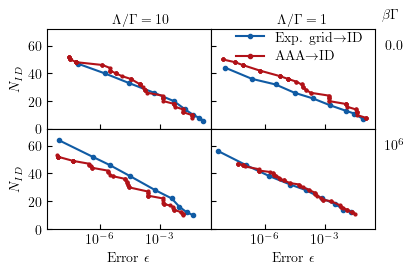

In [151]:
fig, axs = plt.subplots(2, 2, figsize=(4, 3), sharey=True, sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})


norm_times = mcolors.LogNorm(vmin=0.1 * np.min(t_data[t_data > 0]), vmax=4*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    #reset the line cyler to start fresh for each beta
    linecycler = generate_linestyles_cycler(4)
    #for tau in np.arange(kernel_dims_ID[1]-1,0,-4)[::-1]:
    for tau in np.arange(kernel_dims_ID[1]-1,kernel_dims_ID[1]-2,-1)[::-1]:

        err_ID = []
        ID_modes = []
        err_ID2 = []
        ID_modes2 = []
        
        for iter in range (errors_ID.shape[0]):
            err_ID.append(errors_ID[iter, tau, b])
            err_ID2.append(errors_ID2[iter, tau, b])
            ID_modes.append(ID_ranks[iter, tau, b])
            ID_modes2.append(ID_ranks2[iter, tau, b])

        #convert arrays to numpy arrays
        err_ID = np.array(err_ID)
        ID_modes = np.array(ID_modes)
        err_ID2 = np.array(err_ID2)
        ID_modes2 = np.array(ID_modes2)

        linestyle = next(linecycler)
        mask_ID = err_ID > 5.e-9
        mask_ID2 = err_ID2 > 1.e-9

        line_ID, = axs[b,0].plot(err_ID[mask_ID], ID_modes[mask_ID], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])))
        line_ID2, = axs[b,1].plot(err_ID2[mask_ID2], ID_modes2[mask_ID2], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])))


        err_AAA_sc = []
        nbr_poles_sc = []
        err_AAA_sc2 = []
        nbr_poles_sc2 = []
       
        for tol_iter in range(len(tol_vals_sc[:, tau, b])):
            err_AAA_sc.append(errors_AAA_sc[tol_iter, tau, b])
            nbr_poles_sc.append(AAA_ID_rank_particle[tol_iter, tau, b] + AAA_ID_rank_holes[tol_iter, tau, b])
            err_AAA_sc2.append(errors_AAA_sc2[tol_iter, tau, b])
            nbr_poles_sc2.append(AAA_ID_rank_particle2[tol_iter, tau, b] + AAA_ID_rank_holes2[tol_iter, tau, b])
        
        err_AAA_sc = np.array(err_AAA_sc)
        nbr_poles_sc = np.array(nbr_poles_sc)
        err_AAA_sc2 = np.array(err_AAA_sc2)
        nbr_poles_sc2 = np.array(nbr_poles_sc2)

        mask_AAA = err_AAA_sc > 5.e-9
        mask_AAA2 = err_AAA_sc > 2.e-8
        
        line_AAA, = axs[b,0].plot(err_AAA_sc[mask_AAA], nbr_poles_sc[mask_AAA], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])))
        
        line_AAA2, = axs[b,1].plot(err_AAA_sc2[mask_AAA2], nbr_poles_sc2[mask_AAA2], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])))
     


    axs[b,0].set_ylabel(r"$N_{ID}$")
    axs[b,0].set_xscale("log")
    #axs[b,0].set_xlim(right=3.e-1)
    axs[b,0].set_ylim(bottom=0, top = 72)


    axs[b,1].set_xscale("log")
    #axs[b,1].set_xlim(right=3.e-1)
    axs[b,1].set_ylim(bottom=0, top = 72)


axs[-1,0].set_xlabel("Error " + r"$\epsilon$")
axs[-1,1].set_xlabel("Error " + r"$\epsilon$")



# Add a single legend above the entire figure
from matplotlib.legend import Legend


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

#for first row, add a small black arrow to point at one curve. Annotate the arrow with text "blabla"
#axs[0,0].annotate("curves superimposed", xy=(0.001, 6), xytext=(0.4, 0.55), textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='->'))


#write column labels
axs[0,0].text(0.4, 1.05, r'$\Lambda/\Gamma = 10$', transform=axs[0,0].transAxes)
axs[0,1].text(0.4, 1.05, r'$\Lambda/\Gamma = 1$', transform=axs[0,1].transAxes)


#add custom legend for each color above figure
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cmap_blues(norm_times(t_data[-1])), linestyle='-', label='Exp. grid'+r"$\to$" + "ID", marker='o', markersize=3),
                   Line2D([0], [0], color=cmap_reds(norm_times(t_data[-1])), linestyle='-', label='AAA'+r"$\to$" + "ID", marker='o', markersize=3)]
#create legend in subplot [0,1]
axs[0,1].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.1), frameon=False)


#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0.0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$10^6$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))



#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#for right column, move y-axis ticks and labels to the right
#for ax in axs[:,1]:
#    ax.yaxis.set_label_position("right")
#    ax.yaxis.set_ticks_position("right")

#no tick labels for right column
for ax in axs[:,1]:
    ax.yaxis.set_tick_params(labelright=False)

#for left column, set ticks in intervals of 20
for ax in axs[:,0]:
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))


    
#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

#save figure as pdf
fig.savefig("../plots/paper/AAA_linear_exp_cutoff_10vs1.pdf", bbox_inches='tight')





<>:112: SyntaxWarning: invalid escape sequence '\L'
<>:112: SyntaxWarning: invalid escape sequence '\L'
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_98598/3094701126.py:112: SyntaxWarning: invalid escape sequence '\L'
  """axs[0,0].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[0,0].transAxes, color = 'white')


AAA 0.29889318181963453 9.744014108001739
ID 0.28013801270079264 3.5122466813460593
AAA 0.40180479761477994 5.87725961307458
ID 0.4055039159770768 4.986107853713205
global_min 0.28013801270079264
global_max 9.744014108001739
global_min 0.1
global_max 10.0


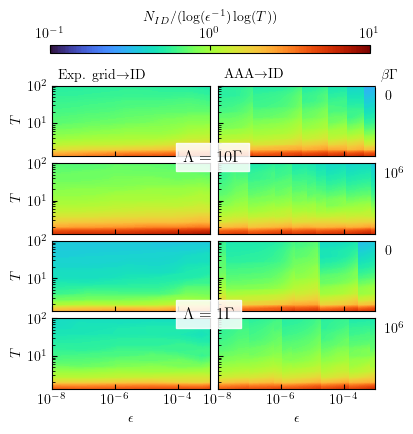

In [154]:
#2D plot that shows N_ID / (log(eps^-1) log(T))

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
#order of indices: h_vals, N_maxs, beta

# Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

fig, axs = plt.subplots(4,2, figsize=(4, 4.2), sharex=True, sharey=True)


global_min = float('inf')
global_max = float('-inf')

# Calculate global min and max
for b, b_idx in enumerate([0, 1]):
    # ID data
    norm_ID = np.log(1/errors_ID[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks[:,1:,b_idx] / norm_ID
    global_min = min(global_min, nbr_modes_rescaled_ID.min())
    global_max = max(global_max, nbr_modes_rescaled_ID.max())

    # AAA data
    norm_AAA = np.log(1/errors_AAA_sc[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle[:,1:,b_idx] + AAA_ID_rank_holes[:,1:,b_idx]) / norm_AAA
    global_min = min(global_min, nbr_modes_rescaled_AAA.min())
    global_max = max(global_max, nbr_modes_rescaled_AAA.max())

    # ID data
    norm_ID = np.log(1/errors_ID2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks2[:,1:,b_idx] / norm_ID
    global_min = min(global_min, nbr_modes_rescaled_ID.min())
    global_max = max(global_max, nbr_modes_rescaled_ID.max())

    # AAA data
    norm_AAA = np.log(1/errors_AAA_sc2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle2[:,1:,b_idx] + AAA_ID_rank_holes2[:,1:,b_idx]) / norm_AAA
    global_min = min(global_min, nbr_modes_rescaled_AAA.min())
    global_max = max(global_max, nbr_modes_rescaled_AAA.max())

    print("AAA", nbr_modes_rescaled_AAA.min(), nbr_modes_rescaled_AAA.max())
    print("ID", nbr_modes_rescaled_ID.min(), nbr_modes_rescaled_ID.max())

print("global_min", global_min)
print("global_max", global_max)

#round to the nearest power of 10
global_min = 10**np.floor(np.log10(global_min))
global_max = 10**np.ceil(np.log10(global_max))
print("global_min", global_min)
print("global_max", global_max)
#normalize the data on a log scale
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=global_min, vmax=global_max)
# Precompute levels on a log scale
levels = np.logspace(np.log10(global_min), np.log10(global_max), 200)

#from matplotlib.colors import Normalize
#norm = Normalize(vmin=global_min, vmax=global_max)
# Precompute levels
#levels = np.linspace(global_min, global_max, 200)

for b, b_idx in enumerate([0, 1]):
    #Lambda = 50
    # ID data
    X, Y = np.meshgrid(errors_ID[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_ID = np.log(1/errors_ID[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks[:,1:,b_idx] / norm_ID 

    contour_ID = axs[b,0].contourf(X, Y, nbr_modes_rescaled_ID.T, cmap="turbo", levels=levels, vmin=global_min, vmax=global_max, norm=norm)
    axs[b,0].set_ylabel(r"$T$")
    axs[b,0].set_xscale("log")
    axs[b,0].set_yscale("log")
    axs[b,0].set_xlim(left=1.e-10, right=1.e-3)

    # AAA data
    X, Y = np.meshgrid(errors_AAA_sc[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_AAA = np.log(1/errors_AAA_sc[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle[:,1:,b_idx] + AAA_ID_rank_holes[:,1:,b_idx]) / norm_AAA 

    contour_AAA = axs[b,1].contourf(X, Y, nbr_modes_rescaled_AAA.T, cmap="turbo", levels=levels, norm=norm)
    axs[b,1].set_xscale("log")
    axs[b,1].set_yscale("log")
    axs[b,1].set_xlim(left=1.e-8, right=1.e-3)

    #Lambda = 1
    # ID data
    X, Y = np.meshgrid(errors_ID2[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_ID = np.log(1/errors_ID2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks2[:,1:,b_idx] / norm_ID 

    contour_ID = axs[b+2,0].contourf(X, Y, nbr_modes_rescaled_ID.T, cmap="turbo", levels=levels, vmin=global_min, vmax=global_max, norm=norm)
    axs[b+2,0].set_ylabel(r"$T$")
    axs[b+2,0].set_xscale("log")
    axs[b+2,0].set_yscale("log")
    axs[b+2,0].set_xlim(left=1.e-10, right=1.e-3)

    # AAA data
    X, Y = np.meshgrid(errors_AAA_sc2[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_AAA = np.log(1/errors_AAA_sc2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle2[:,1:,b_idx] + AAA_ID_rank_holes2[:,1:,b_idx]) / norm_AAA 

    contour_AAA = axs[b+2,1].contourf(X, Y, nbr_modes_rescaled_AAA.T, cmap="turbo", levels=levels, norm=norm)
    axs[b+2,1].set_xscale("log")
    axs[b+2,1].set_yscale("log")
    axs[b+2,1].set_xlim(left=1.e-8, right=1.e-3)

axs[-1,0].set_xlabel(r"$\epsilon$")
axs[-1,1].set_xlabel(r"$\epsilon$")

"""axs[0,0].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[0,0].transAxes, color = 'white')
axs[1,0].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[1,0].transAxes, color = 'white')
axs[0,1].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[0,1].transAxes, color = 'white')
axs[1,1].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[1,1].transAxes, color = 'white')

axs[2,0].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[2,0].transAxes, color = 'white')
axs[3,0].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[3,0].transAxes, color = 'white')
axs[2,1].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[2,1].transAxes, color = 'white')
axs[3,1].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[3,1].transAxes, color = 'white')"""
#transparent white background color for text
fig.text(0.83,-.07,r"$\Lambda = 10\Gamma$", transform=axs[0,0].transAxes, color = 'black', backgroundcolor=(1, 1, 1, 0.85), fontsize='large')
fig.text(0.83,-2.3,r"$\Lambda = 1\Gamma$", transform=axs[0,0].transAxes, color = 'black', backgroundcolor=(1, 1, 1, 0.85), fontsize='large')

plt.tight_layout(rect=[0, 0, 1, 0.9])
cax_ID = fig.add_axes([0.15, 0.93, 0.8, 0.02])

fig.subplots_adjust(hspace=0.1, wspace=0.05)

cbar_ID = fig.colorbar(contour_AAA, cax=cax_ID, orientation='horizontal')

#print range of values
cbar_ID.set_ticks([.1, 1, 10])
#for the colobar ranging from 0.1 to 10, set a tick at every integer value
#cbar_ID.set_ticks([0, 1, 10])






cbar_ID.ax.xaxis.set_ticks_position('top')
cbar_ID.ax.xaxis.set_label_position('top')
cbar_ID.ax.tick_params(axis='x', which='both', direction='in', top=True, bottom=False)
cbar_ID.set_label(r"$N_{ID} / (\log(\epsilon^{-1}) \log(T))$", labelpad=5, fontsize='medium')


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#label for each column
fig.text(0.28, 0.87, "Exp. grid"+r'$\to$' + "ID", ha='center')
fig.text(0.66, 0.87, "AAA"+r'$\to$' + "ID", ha='center')

#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$10^6$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[2,1].text(1.06, 0.8, r"$0$", transform=axs[2,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[3,-1].text(1.06, 0.8, r"$10^6$", transform=axs[3,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))


#second figure for Lambda=1
#save the figure as a PDF
plt.savefig('../plots/paper/complexity_linear_Lambda10vs1.pdf', format='pdf', bbox_inches='tight')

In [245]:
filename_ID = f'../data/paper/paper_ID_gapped_gaussian.h5'

#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)


#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "only_positive_particle", "additional_poles", "explicit_poles"]

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

nbr_additional_poles = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]



filename_AAA_sc = f'../data/paper/paper_AAA_gapped_gaussians.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_rank_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc = data_h5_AAA_sc["N_max"]
betas_sc = data_h5_AAA_sc["beta"]
delta_t_vals_sc = data_h5_AAA_sc["delta_t"]
tol_vals_sc = data_h5_AAA_sc["tol"]
Z_vals_sc = data_h5_AAA_sc["Z"]
F_vals_sc = data_h5_AAA_sc["F_particle"]


t_data = np.array([np.max(N_maxs_sc[:,tau,:] * delta_t_vals_sc[:,tau,:]) for tau in range (kernel_dims_AAA_sc[1])])

print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")
#print("errors AAA ", errors_AAA_sc)
#print("nbr_poles_upper ", nbr_poles_upper_sc)

filename_AAA = f'../data/paper/paper_AAA_semicircle_smooth_0.8_sharpness20.h5'

h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)


kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc2 = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc2 = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle2 = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes2 = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc2 = data_h5_AAA_sc["N_max"]
betas_sc2 = data_h5_AAA_sc["beta"]
delta_t_vals_sc2 = data_h5_AAA_sc["delta_t"]
tol_vals_sc2 = data_h5_AAA_sc["tol"]
Z_vals_sc2 = data_h5_AAA_sc["Z"]
F_vals_sc2 = data_h5_AAA_sc["F_particle"]

def get_idx(tol, tau, beta):
    return tol * kernel_dims_AAA_sc[1] *  kernel_dims_AAA_sc[2] + tau * kernel_dims_AAA_sc[2] + beta

# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-','--', '-.', ':']
    return cycle(predefined_linestyles[:n])



Dimensions of data arrays: [100  15   2].


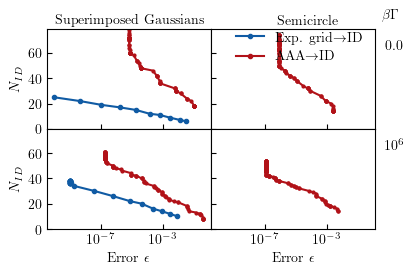

In [248]:
fig, axs = plt.subplots(2, 2, figsize=(4, 3), sharey=True, sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})


norm_times = mcolors.LogNorm(vmin=0.1 * np.min(t_data[t_data > 0]), vmax=4*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    #reset the line cyler to start fresh for each beta
    linecycler = generate_linestyles_cycler(4)
    #for tau in np.arange(kernel_dims_ID[1]-1,0,-4)[::-1]:
    for tau in np.arange(kernel_dims_ID[1]-1,kernel_dims_ID[1]-2,-1)[::-1]:

        err_ID = []
        ID_modes = []
        
        for iter in range (errors_ID.shape[0]):
            err_ID.append(errors_ID[iter, tau, b])
            ID_modes.append(ID_ranks[iter, tau, b])

        #convert arrays to numpy arrays
        err_ID = np.array(err_ID)
        ID_modes = np.array(ID_modes)

        linestyle = next(linecycler)
        mask_ID = err_ID > 1.e-11

        line_ID, = axs[b,0].plot(err_ID[mask_ID], ID_modes[mask_ID], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])))
    


        err_AAA_sc = []
        nbr_poles_sc = []
        err_AAA_sc2 = []
        nbr_poles_sc2 = []
       
        for tol_iter in range(len(tol_vals_sc[:, tau, b])):
            err_AAA_sc.append(errors_AAA_sc[tol_iter, tau, b])
            nbr_poles_sc.append(AAA_ID_rank_particle[tol_iter, tau, b] + AAA_ID_rank_holes[tol_iter, tau, b])
            err_AAA_sc2.append(errors_AAA_sc2[tol_iter, tau, b])
            nbr_poles_sc2.append(AAA_ID_rank_particle2[tol_iter, tau, b] + AAA_ID_rank_holes2[tol_iter, tau, b])
        
        err_AAA_sc = np.array(err_AAA_sc)
        nbr_poles_sc = np.array(nbr_poles_sc)
        err_AAA_sc2 = np.array(err_AAA_sc2)
        nbr_poles_sc2 = np.array(nbr_poles_sc2)

        #if b == 0:
        #    mask_AAA = err_AAA_sc > 1.e-5
        #else:
        #    mask_AAA = err_AAA_sc > 1.e-6
        #mask_AAA2 = err_AAA_sc2 > 1.e-5
        mask_AAA = err_AAA_sc > 0
        mask_AAA2 = err_AAA_sc2 > 0
        line_AAA, = axs[b,0].plot(err_AAA_sc[mask_AAA], nbr_poles_sc[mask_AAA], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])))
        
        line_AAA2, = axs[b,1].plot(err_AAA_sc2[mask_AAA2], nbr_poles_sc2[mask_AAA2], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])))
     


    axs[b,0].set_ylabel(r"$N_{ID}$")
    axs[b,0].set_xscale("log")
    #axs[b,0].set_xlim(right=3.e-1)
    axs[b,0].set_ylim(bottom=0, top = 79)


    axs[b,1].set_xscale("log")
    #axs[b,1].set_xlim(right=3.e-1)
    axs[b,1].set_ylim(bottom=0, top = 79)


axs[-1,0].set_xlabel("Error " + r"$\epsilon$")
axs[-1,1].set_xlabel("Error " + r"$\epsilon$")



# Add a single legend above the entire figure
from matplotlib.legend import Legend


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

#for first row, add a small black arrow to point at one curve. Annotate the arrow with text "blabla"
#axs[0,0].annotate("curves superimposed", xy=(0.001, 6), xytext=(0.4, 0.55), textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='->'))


#write column labels
axs[0,0].text(0.05, 1.05, "Superimposed Gaussians", transform=axs[0,0].transAxes)
axs[0,1].text(0.4, 1.05, "Semicircle", transform=axs[0,1].transAxes)


#add custom legend for each color above figure
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cmap_blues(norm_times(t_data[-1])), linestyle='-', label='Exp. grid'+r"$\to$" + "ID", marker='o', markersize=3),
                   Line2D([0], [0], color=cmap_reds(norm_times(t_data[-1])), linestyle='-', label='AAA'+r"$\to$" + "ID", marker='o', markersize=3)]
#create legend in subplot [0,1]
axs[0,1].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.1), frameon=False)


#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0.0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$10^6$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))



#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#for right column, move y-axis ticks and labels to the right
#for ax in axs[:,1]:
#    ax.yaxis.set_label_position("right")
#    ax.yaxis.set_ticks_position("right")

#no tick labels for right column
for ax in axs[:,1]:
    ax.yaxis.set_tick_params(labelright=False)

#for left column, set ticks in intervals of 20
for ax in axs[:,0]:
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))


    
#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

#save figure as pdf
fig.savefig("../plots/paper/error_scaling_gapped_gaussian_semicirc.pdf", bbox_inches='tight')





global_min 0.1
global_max 10


/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_98598/3863200094.py:80: UserWarning: Adding colorbar to a different Figure <Figure size 400x220 with 5 Axes> than <Figure size 400x220 with 5 Axes> which fig.colorbar is called on.
  cbar_ID = fig.colorbar(contour_AAA, cax=cax_ID, orientation='horizontal')


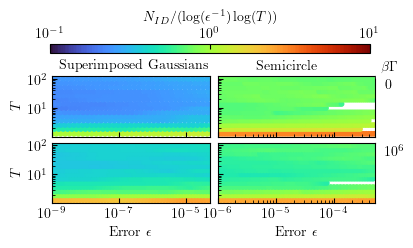

In [372]:

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
#order of indices: h_vals, N_maxs, beta

# Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

fig, axs = plt.subplots(2,2, figsize=(4, 2.2), sharex="col", sharey=True)

global_min = 0.1
global_max = 10
print("global_min", global_min)
print("global_max", global_max)
#normalize the data on a log scale
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=global_min, vmax=global_max)
from scipy.interpolate import griddata


for b, b_idx in enumerate([0, 1]):
    # Gather all data points
    for tau in range(1, kernel_dims_ID[1]):

        time = N_maxs[0, tau, b_idx] * delta_t_vals[0, tau, b_idx]

        #ID for superimposed Gaussians:
        #mask for errors
        mask_error = errors_ID[:, tau, b_idx] > 0
        #error values
        x = errors_ID[mask_error, tau, b_idx]
        #norm
        norm_ID = np.log(1 / x) * np.log(time)
        #function values
        z = ID_ranks[mask_error, tau, b_idx] / norm_ID 
        # Create a grid for the interpolation
        xi_log = np.linspace(np.log10(x.min()), np.log10(x.max()), 100)
        # Interpolate the data using linear interpolation
        zi_log = griddata(np.log10(x), z, xi_log, method='linear')
        # Scatter plot with interpolated values
        axs[b, 0].scatter(10**xi_log, np.full_like(xi_log, time), c=zi_log, cmap="turbo", norm=norm, s=10)

        #AAA for semicircle
        #mask for errors
        mask_error = errors_AAA_sc2[:, tau, b_idx] > 0
        #error values
        x = errors_AAA_sc2[mask_error, tau, b_idx]
        #norm
        norm_AAA = np.log(1 / x) * np.log(time)
        #function values
        z = (AAA_ID_rank_particle2[mask_error, tau, b_idx] + AAA_ID_rank_holes2[mask_error, tau, b_idx]) / norm_AAA
        # Create a grid for the interpolation
        xi_log = np.linspace(np.log10(x.min()), np.log10(x.max()), 100)
        # Interpolate the data using linear interpolation
        zi_log = griddata(np.log10(x), z, xi_log, method='linear')
        # Scatter plot with interpolated values
        axs[b, 1].scatter(10**xi_log, np.full_like(xi_log, time), c=zi_log, cmap="turbo", norm=norm, s=10)



    
 
    axs[b,0].set_ylabel(r"$T$")
    axs[b,0].set_xscale("log")
    axs[b,0].set_yscale("log")
    axs[b,0].set_xlim(left=1.e-9, right=.5e-4)
    axs[b,1].set_xscale("log")
    axs[b,1].set_yscale("log")
    axs[b,1].set_xlim(left=1.e-6, right=.5e-3)

axs[-1,0].set_xlabel("Error " +r"$\epsilon$")
axs[-1,1].set_xlabel("Error " +r"$\epsilon$")



plt.tight_layout(rect=[0, 0, 1, 0.9])
cax_ID = fig.add_axes([0.15, 0.93, 0.8, 0.04])

fig.subplots_adjust(hspace=0.1, wspace=0.05)

cbar_ID = fig.colorbar(contour_AAA, cax=cax_ID, orientation='horizontal')

#print range of values
cbar_ID.set_ticks([.1, 1, 10])
#for the colobar ranging from 0.1 to 10, set a tick at every integer value
#cbar_ID.set_ticks([0, 1, 10])


cbar_ID.ax.xaxis.set_ticks_position('top')
cbar_ID.ax.xaxis.set_label_position('top')
cbar_ID.ax.tick_params(axis='x', which='both', direction='in', top=True, bottom=False)
cbar_ID.set_label(r"$N_{ID} / (\log(\epsilon^{-1}) \log(T))$", labelpad=5, fontsize='medium')


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#label for each column
fig.text(0.36, 0.86, "Superimposed Gaussians", ha='center')
fig.text(0.74, 0.86, "Semicircle", ha='center')

#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$10^6$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))



#save figure as pdf
fig.savefig("../plots/paper/complexity_AAA_gaussians_semicircle.pdf", bbox_inches='tight')

In [48]:
filename_AAA_sc = f'../data/paper/paper_AAA_Lambda50_lowtemp.h5'
#Create instance of Hdf5Kernel
h5_kernel_AAA_sc = Hdf5Kernel(filename=filename_AAA_sc)
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_poles_particle_upper","ID_poles_hole_upper", "poles_particle_upper", "poles_hole_upper", "ID_residues_hole_upper", "ID_residues_particle_upper", "residues_hole_upper", "residues_particle_upper", "poles_particle", "poles_hole", "residues_particle", "residues_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA_sc.read_scalars_to_array(keys=keys_sc)

ID_poles_particle_upper = data_h5_AAA_sc["ID_poles_particle_upper"]
ID_poles_hole_upper = data_h5_AAA_sc["ID_poles_hole_upper"]
ID_residues_hole_upper = data_h5_AAA_sc["ID_residues_hole_upper"]
ID_residues_particle_upper = data_h5_AAA_sc["ID_residues_particle_upper"]
poles_particle_upper = data_h5_AAA_sc["poles_particle_upper"]
poles_hole_upper = data_h5_AAA_sc["poles_hole_upper"]
residues_hole_upper = data_h5_AAA_sc["residues_hole_upper"]
residues_particle_upper = data_h5_AAA_sc["residues_particle_upper"]
poles_particle = data_h5_AAA_sc["poles_particle"]
poles_hole = data_h5_AAA_sc["poles_hole"]
residues_particle = data_h5_AAA_sc["residues_particle"]
residues_hole = data_h5_AAA_sc["residues_hole"]
betas = data_h5_AAA_sc["beta"]


errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
N_maxs_sc = data_h5_AAA_sc["N_max"]

#print kernel dims
print(f"Dimensions of data arrays: {kernel_dims_AAA_sc}.")


Dimensions of data arrays: [100  15   5].


1000
1.7373905434617806e-11
193


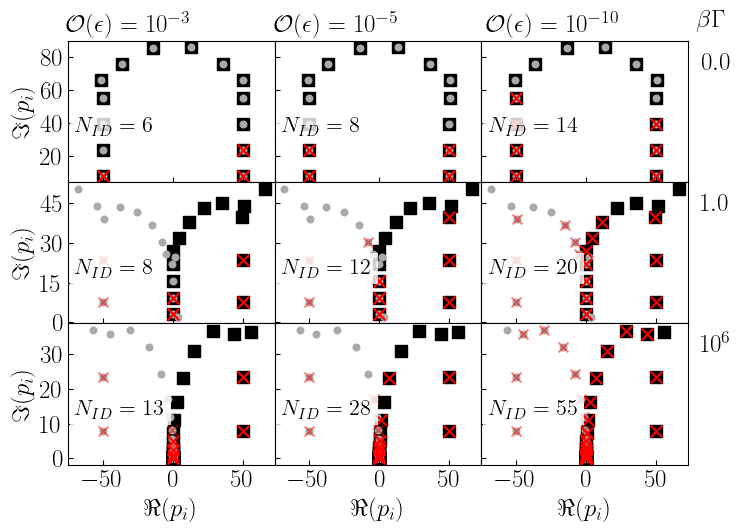

In [56]:
def get_idx(tol, tau, beta):
    return tol * kernel_dims_AAA_sc[1] *  kernel_dims_AAA_sc[2] + tau * kernel_dims_AAA_sc[2] + beta

#for proper representaiton of exponentials
from matplotlib.ticker import FuncFormatter

# Function to format the tick labels
def scientific_notation(x, pos):
    if x == 0:
        return "0"
    exponent = int(np.floor(np.log10(np.abs(x))))
    coeff = x / 10**exponent
    return r"${:.2f} \times 10^{{{}}}$".format(coeff, exponent)

cmap_reds = plt.get_cmap("Reds_r")
norm_errors = mcolors.LogNorm(vmin=0.1*np.min(errors_AAA_sc[:30,:,:]), vmax=2*np.max(errors_AAA_sc[:30,:,:]))
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 18})
#plot poles
fig, axs = plt.subplots(3, 3, figsize=(8, 5.5), sharex=True, sharey='row')

#idx axes: tol, tau, beta
tau= 14
#print value of N_max
print(N_maxs_sc[0,tau,0])

for beta_idx, beta in enumerate([0,1,4]):
    for tol_idx, tol in enumerate([0,20,80]):
        idx = get_idx(tol, tau, beta)
        #plot all poles before compression
        axs[beta_idx, tol_idx].scatter(np.real(poles_particle_upper[idx]), np.imag(poles_particle_upper[idx]), marker = 's', linestyle = 'None', color = 'black', s = 70)
        axs[beta_idx, tol_idx].scatter(np.real(poles_hole_upper[idx]), np.imag(poles_hole_upper[idx]), marker = '.', linestyle = 'None', color = 'darkgrey', s = 90)
       
        #convert error to scientific notation as 10^{-x} in order to print the numbers
        formatted_number = f"{errors_AAA_sc[tol, tau, beta_idx]:.1e}"
        coeff, exponent = formatted_number.split('e')

        #axs[beta_idx, tol_idx].text(0.035, 0.55, fr"$\epsilon = {coeff} \times 10^{{{int(exponent)}}}$", transform=axs[beta_idx, tol_idx].transAxes,  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'))
        N_ID = len(ID_poles_particle_upper[idx]) + len(ID_poles_hole_upper[idx]) #number of modes
        axs[beta_idx, tol_idx].text(0.035, 0.35, f"$N_{{ID}} = {N_ID}$", transform=axs[beta_idx, tol_idx].transAxes,  bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=16)
        
        #plot the poles kept by the ID
        #axs[beta_idx, tol_idx].scatter(np.real(ID_poles_hole_upper[idx]), np.imag(ID_poles_hole_upper[idx]), facecolors='none', edgecolors="red", linewidth = 2,linestyle = '-', s = 170, alpha = 0.5)
        #axs[beta_idx, tol_idx].scatter(np.real(ID_poles_particle_upper[idx]), np.imag(ID_poles_particle_upper[idx]), facecolors='none', edgecolors="red", linewidth = 2, linestyle = 'dashed', s = 200)
        axs[beta_idx, tol_idx].scatter(np.real(ID_poles_hole_upper[idx]), np.imag(ID_poles_hole_upper[idx]), marker = 'x', linestyle = 'None', color = 'red', s = 50, alpha = 0.5)
        axs[beta_idx, tol_idx].scatter(np.real(ID_poles_particle_upper[idx]), np.imag(ID_poles_particle_upper[idx]), marker = 'x', linestyle = 'None', color = 'red', s = 70)
    

print(errors_AAA_sc[80,9,0])
print(N_maxs_sc[80,9,1])

#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')
    # Ensure y-axis ticks are integers
    from matplotlib.ticker import MaxNLocator
    ax.yaxis.set_major_locator(MaxNLocator(integer=True))
    # Reduce the density of y-axis labels
    ax.yaxis.set_major_locator(MaxNLocator(nbins=5))  # Change nbins to the desired number of ticks

    #ax.set_xlim(-60, 60)
    #ax.set_ylim(0, 60.9)

for ax in axs[-1,:]:
    ax.set_xlabel(r"$\Re(p_i)$")
for ax in axs[:,0]:
    ax.set_ylabel(r"$\Im(p_i)$")

#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0.0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$1.0$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[2,1].text(1.06, 0.8, r"$10^6$", transform=axs[2,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))

    
#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

#text above figure
fig.text(.2, 0.91, r"$\mathcal{O}(\epsilon) = 10^{-3}$", ha='center', va='center')
fig.text(.46, 0.91, r"$\mathcal{O}(\epsilon) = 10^{-5}$", ha='center', va='center')
fig.text(.73, 0.91, r"$\mathcal{O}(\epsilon) = 10^{-10}$", ha='center', va='center')


# Save the figure as a PDF
plt.savefig('../plots/paper/AAA_poles_flatband_Lambda=50_.pdf', format='pdf', bbox_inches='tight')

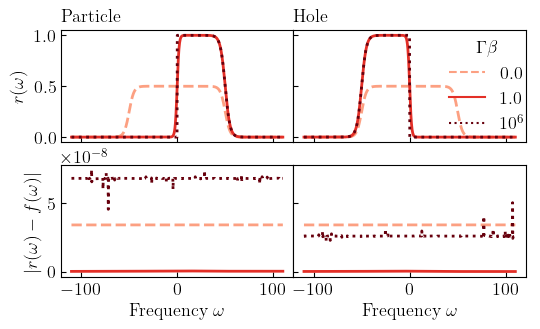

In [553]:
def rational_approximation(poles, residues, z):
    return np.sum(np.array([residue/(z[:,np.newaxis] - pole) for pole, residue in zip(poles, residues)]), axis = 0).flatten()

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['--','-', ':']
    return cycle(predefined_linestyles[:n])

linestyles = generate_linestyles_cycler(kernel_dims_ID[1])
linecycler = cycle(linestyles)

#create red colormap for beta values
cmap_reds = plt.get_cmap("Reds")
norm_betas = mcolors.Normalize(vmin=-1, vmax=2)



#use ID_poles_particle_upper, ID_residues_particle_upper, ID_poles_hole_upper, ID_residues_hole_upper
z = np.linspace(-110, 110, 1000) 

from src.spec_dens.spec_dens import spec_dens_gapless, spec_dens_semi_circle
def compare_p(z, beta_val):
    return cf.fermi_dirac(z, -beta_val) * spec_dens_gapless(z, cutoff_lower= -50, cutoff_upper=50, sharpness=20./50) 
    #return  cf.fermi_dirac(z, -beta_val) * (spec_dens_gapless(z, cutoff_lower= -20, cutoff_upper=-5, sharpness=2) + spec_dens_gapless(z, cutoff_lower= 5, cutoff_upper=20, sharpness=2))
    #return cf.fermi_dirac(z, -beta_val) * abs(z) * np.exp(-abs(z) / 10)
#plot
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 13})
fig, axs = plt.subplots(2, 2, figsize=(6, 3.2), sharey='row')
for beta_idx, beta in enumerate([0,1,4]):
    linestyle = next(linecycler)
    beta_val = betas[0,0,beta]

    idx = get_idx(0,0,beta)#first two indices don't matter as we analyze the "bare" (uncompressed) grid which is always the same
    poles_p = poles_particle[idx]
    residues_p =  residues_particle[idx]
    poles_h = poles_hole[idx]
    residues_h =  residues_hole[idx]

    #construct rational approximation from poles and residues
    f_p = rational_approximation(poles_p, residues_p, z)
    f_h = rational_approximation(poles_h, residues_h, z)
    compare_particle = compare_p(z, beta_val)
    compare_hole = compare_p(z, -beta_val)

    #plot data with different red colors for different beta values
    axs[0,0].plot(z, np.real(f_p), linestyle = linestyle, label = r"$r^p(\omega)$", color = cmap_reds(norm_betas(beta_idx)), linewidth = 2)
    axs[0,1].plot(z, np.real(f_h), linestyle = linestyle, label = r"$r^h(\omega)$", color = cmap_reds(norm_betas(beta_idx)), linewidth = 2)


    axs[1,0].plot(z, abs(f_p- compare_particle), linestyle = linestyle, label = f"\beta{beta_val}", color = cmap_reds(norm_betas(beta_idx)), linewidth = 2)
    axs[1,1].plot(z, abs(f_h- compare_hole), linestyle = linestyle, label = "hole", color = cmap_reds(norm_betas(beta_idx)), linewidth = 2)
    
 
#add a manual legend with the lines of the main plots
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cmap_reds(norm_betas(0)), linestyle='--', label=r'$0.0$'),
                   Line2D([0], [0], color=cmap_reds(norm_betas(1)), linestyle='-', label=r'$1.0$'),
                   Line2D([0], [0], color=cmap_reds(norm_betas(2)), linestyle=':', label=r'$10^6$')]

#place the legend above the plotting area and remove the frame
axs[0,1].legend(handles=legend_elements, loc='upper center', bbox_to_anchor=(.83, 1.05), ncol=1, frameon=False, title=r"$\Gamma \beta$")

#add a title to each column woth small text size
axs[0,0].set_title("Particle", fontsize = 13, loc='left')
axs[0,1].set_title("Hole", fontsize= 13, loc='left')


    
#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')


axs[-1,0].set_xlabel("Frequency "+ r"$\omega$")
axs[-1,1].set_xlabel("Frequency "+ r"$\omega$")
axs[0,0].set_ylabel(r"$r(\omega)$")
axs[1,0].set_ylabel(r"$|r(\omega) - f(\omega)|$")
#turn off tick labels for first plot
axs[0,0].set_xticklabels([])
axs[0,1].set_xticklabels([])

#move columns closer together
fig.subplots_adjust(wspace=0.0)
# Save the figure as a PDF
plt.savefig('../plots/paper/rational_approx_error_flatband_error_Lambda=50.pdf', format='pdf', bbox_inches='tight')

nbr. additional poles 0
nbr. explicit poles 12


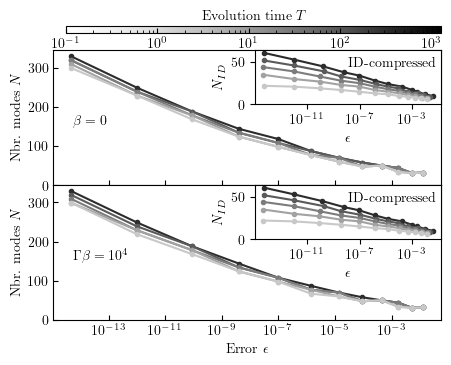

In [597]:
filename_ID = f'../data/paper/paper_ID_Lambda100000_opt_onlypos.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "only_positive_particle", "additional_poles", "explicit_poles"]


cmap_grays = plt.get_cmap("Greys")
#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)


errors_discretization = data_h5_ID["eps"]
nbr_additional_poles = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
print("nbr. additional poles", nbr_additional_poles)
print("nbr. explicit poles", nbr_explicit_poles)
m_vals = data_h5_ID["m"] 
n_vals = data_h5_ID["n"]
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
N_modes_finegrid = ((m_vals + n_vals) + 1) + nbr_explicit_poles/2


t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

fig, axs = plt.subplots(2, 1, figsize=(5, 3.5), sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

# Collect handles and labels for the legend
handles_ID = []
labels_ID = []
handles_bare = []
labels_bare = []

norm_times = mcolors.LogNorm(vmin=0.1 * np.min(t_data[t_data > 0]), vmax=4*np.max(t_data))

for b in range(kernel_dims_ID[2]):

    #create inset of ID data
    axin = axs[b].inset_axes([0.52, 0.6, 0.48, 0.4])

    for tau in range(len(t_data)-1, 0, -3):

        err_ID = []
        ID_modes = []
        err_disc = []
        nbr_bare_modes = []
        
        for iter in range (errors_ID.shape[0]):
            err_ID.append(errors_ID[iter, tau, b])
            err_disc.append(errors_discretization[iter, tau, b])
            ID_modes.append(ID_ranks[iter, tau, b])
            nbr_bare_modes.append(N_modes_finegrid[iter, tau, b])

        #convert arrays to numpy arrays
        err_ID = np.array(err_ID)
        ID_modes = np.array(ID_modes)
        err_disc = np.array(err_disc)
        nbr_bare_modes = np.array(nbr_bare_modes)

    
        mask_ID = err_ID > 4.e-15

        line_ID, = axin.plot(err_ID[mask_ID], ID_modes[mask_ID], marker="o", linestyle="-", markersize=3, 
                               color=cmap_grays(norm_times(t_data[tau])))


        mask_bare = err_disc > 4.e-15
        #+ np.array(np.sum(mask_bare) * [nbr_additional_poles])
        line_bare, = axs[b].plot(err_disc[mask_bare], nbr_bare_modes[mask_bare] , marker="o", linestyle="-", markersize=3, color=cmap_grays(norm_times(t_data[tau])), 
                          label= str(round(t_data[tau], 2)))

        # Collect legend handles and labels for unique time values
        if line_bare.get_label() not in labels_bare:
            handles_bare.append(line_bare)
            labels_bare.append(line_bare.get_label())


    
    axs[b].set_ylabel("Nbr. modes " + r"$N$")
    axs[b].set_xscale("log")
    axs[b].set_ylim(bottom=0)

    axin.set_ylabel(r"$N_{ID}$")
    axin.set_xlabel(r"$\epsilon$")
    axin.set_xscale("log")
    axin.set_ylim(bottom=0)
    axin.text(0.5, 0.7, "ID-compressed", transform=axin.transAxes)

axs[1].set_xlabel("Error " + r"$\epsilon$")
#for text inset, choose background color white
axs[0].text(0.05, 0.45, r"$\beta = 0$", transform=axs[0].transAxes, backgroundcolor='white')
axs[1].text(0.05, 0.45, r"$\Gamma\beta  = 10^4$", transform=axs[1].transAxes, backgroundcolor='white')

# Add a single legend above the entire figure
from matplotlib.legend import Legend



# Add a colorbar for the reds above the figure
cax_grays = fig.add_axes([0.15, .93, 0.75, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_times)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label("Evolution time " + r'$T$', labelpad=5, fontsize='medium')
# Place ticks inside the red colorbar
cbar_grays.ax.tick_params(axis='x', which='both', direction='in')

# Ensure the colorbars are aligned and share the same title
cbar_grays.ax.xaxis.set_label_position('top')


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

# Save the figure as a PDF
plt.savefig('../plots/paper/flatband_error_Lambda=100000_pos.pdf', format='pdf', bbox_inches='tight')


Errors Discretization: [[[1.25433779e-16 1.00880901e-16]
  [1.20794230e-16 9.15757695e-17]
  [1.18567284e-16 9.63780278e-17]
  [1.15548311e-16 9.95897619e-17]
  [1.10559757e-16 9.91610307e-17]
  [1.10460173e-16 9.91403591e-17]
  [1.08443016e-16 9.91079781e-17]
  [1.07335312e-16 9.94320675e-17]
  [1.06937956e-16 9.91803733e-17]
  [1.07112536e-16 9.98937116e-17]
  [1.06607940e-16 1.00689977e-16]
  [1.05474645e-16 1.01345465e-16]
  [1.08518089e-16 1.05035079e-16]
  [1.21355752e-16 1.12565945e-16]
  [1.46977763e-16 1.23575350e-16]]

 [[1.47783124e-16 1.43943268e-16]
  [1.40410263e-16 1.33480508e-16]
  [1.38620539e-16 1.31565243e-16]
  [1.32930916e-16 1.30780786e-16]
  [1.25847662e-16 1.29202408e-16]
  [1.22796730e-16 1.25388938e-16]
  [1.19057765e-16 1.22751020e-16]
  [1.18077382e-16 1.21969280e-16]
  [1.16644766e-16 1.20769568e-16]
  [1.15752980e-16 1.19746049e-16]
  [1.14805997e-16 1.18886764e-16]
  [1.13288345e-16 1.18621395e-16]
  [1.15738077e-16 1.20912479e-16]
  [1.27813505e-16 1.273

/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_55498/1144846241.py:121: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


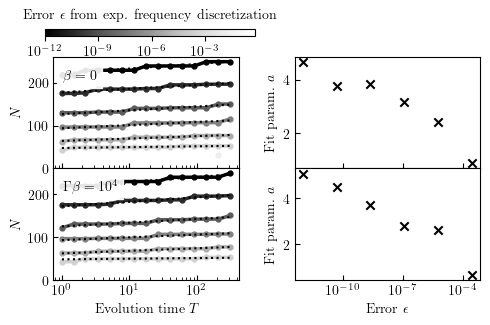

In [294]:

filename_ID = f'../data/paper/paper_ID_Lambda100000_opt_onlypos.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "explicit_poles"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]


nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_modes_finegrid = (m_vals + n_vals) + 1 + nbr_explicit_poles / 2 #factor 1/2 because here we consider only positive frequencies

print(f"Errors Discretization: {errors_discretization}")
print(f"Errors ID: {errors_ID}")


# Set global fontsize using rcParams


cmap_grays = plt.get_cmap("Greys_r")
# Configuration and data preparation
nbr_interpolations = 7

#smallest nonzero error
error_min_discr = np.min(errors_discretization[errors_discretization > 0])


error_grid_discretization = np.logspace(np.log10(np.max([error_min_discr,1.e-12])), np.log10(np.max(errors_discretization)), nbr_interpolations)


fig, axs = plt.subplots(kernel_dims_ID[2], 2, figsize=(5, 3.2), sharex='col')
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

N_modes_finegrid_interp = np.zeros((len(error_grid_discretization), kernel_dims_ID[1]))

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Use logarithmic normalization
norm_bare = mcolors.LogNorm(vmin=error_grid_discretization[0], vmax=50*error_grid_discretization[-1])


        
# Interpolation and plotting ID data
for b in range (kernel_dims_ID[2]):#loop over beta values

 
    fitting_params_a_bare = np.zeros((len(error_grid_discretization),))

    for tau in range (kernel_dims_ID[1]):#loop over final time values, N_max
  
        mask_discretization = errors_discretization[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        N_MODES_FINE_INTERP = DataInterp(errors_discretization[mask_discretization, tau,b], N_modes_finegrid[mask_discretization, tau,b])
        N_modes_finegrid_interp[:, tau] = N_MODES_FINE_INTERP.interp(error_grid_discretization, x_scale='log')
       
        

    for eps_iter in range(len(error_grid_discretization)):
        #plot only nonzero values
        mask_N_modes_fine = N_modes_finegrid_interp[eps_iter, :] > 0.
       
        error_bare = error_grid_discretization[eps_iter]
        #plot interpolated data
        axs[b,0].plot(t_data[mask_N_modes_fine], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine], marker="o", linestyle="-", markersize=3.5, linewidth = 2.5, color=cmap_grays(norm_bare(error_bare)))

         #fit logarithmic curves
        if sum(mask_N_modes_fine) > 1:
            params_bare = fit_logarithmic(t_data[mask_N_modes_fine][2:], N_modes_finegrid_interp[eps_iter, mask_N_modes_fine][2:])
         
            fitting_params_a_bare[eps_iter] = params_bare[0]

            #plot fitting function
            axs[b,0].plot(t_data[mask_N_modes_fine], log_func(t_data[mask_N_modes_fine], *params_bare), color="black", linestyle="dotted", linewidth=1.5)
            #plot fitting parameters
            axs[b,1].scatter(error_bare, params_bare[0], marker="x",  color=cmap_grays(1))

       
    axs[b,0].set_ylabel(r"$N$")
    axs[b,1].set_ylabel("Fit param. " + r'$a$')  

    axs[b,0].set_xscale('log')
    axs[b,1].set_xscale('log')

    axs[b,0].set_ylim(bottom=0)


#for text inset, choose background color white
axs[0,0].text(0.05, 0.8, r"$\beta = 0$", transform=axs[0,0].transAxes, backgroundcolor=(1, 1, 1, 0.9))  # backgroundcolor white with 50% opacity
axs[1,0].text(0.05, 0.8, r"$\Gamma\beta = 10^4$", transform=axs[1,0].transAxes, backgroundcolor=(1, 1, 1, 0.9))
# Setting labels and legend
axs[-1,0].set_xlabel("Evolution time " + r'$T$')
axs[-1,1].set_xlabel("Error " + r'$\epsilon$')

# Add a colorbar for the grays above the figure
cax_grays = fig.add_axes([0.1, 0.92, 0.42, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_bare)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label('Error ' + r'$\epsilon$' + " from exp. frequency discretization", labelpad=-35, fontsize='medium')



#move all ticks into plotting area
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars

#move lower plots closer to upper plots, such that the upper edge of the lower plots zouces with the lower edge of the upper plots. do not use subplots_adjust
fig.subplots_adjust(hspace=0.0, wspace=.3)

# Save the figure as a PDF
plt.savefig('../plots/paper/flatband_bare_time_dependence_Lambda100000_pos.pdf', format='pdf', bbox_inches='tight')


Errors Discretization: [[[1.25433779e-16 1.00880901e-16]
  [1.20794230e-16 9.15757695e-17]
  [1.18567284e-16 9.63780278e-17]
  [1.15548311e-16 9.95897619e-17]
  [1.10559757e-16 9.91610307e-17]
  [1.10460173e-16 9.91403591e-17]
  [1.08443016e-16 9.91079781e-17]
  [1.07335312e-16 9.94320675e-17]
  [1.06937956e-16 9.91803733e-17]
  [1.07112536e-16 9.98937116e-17]
  [1.06607940e-16 1.00689977e-16]
  [1.05474645e-16 1.01345465e-16]
  [1.08518089e-16 1.05035079e-16]
  [1.21355752e-16 1.12565945e-16]
  [1.46977763e-16 1.23575350e-16]]

 [[1.47783124e-16 1.43943268e-16]
  [1.40410263e-16 1.33480508e-16]
  [1.38620539e-16 1.31565243e-16]
  [1.32930916e-16 1.30780786e-16]
  [1.25847662e-16 1.29202408e-16]
  [1.22796730e-16 1.25388938e-16]
  [1.19057765e-16 1.22751020e-16]
  [1.18077382e-16 1.21969280e-16]
  [1.16644766e-16 1.20769568e-16]
  [1.15752980e-16 1.19746049e-16]
  [1.14805997e-16 1.18886764e-16]
  [1.13288345e-16 1.18621395e-16]
  [1.15738077e-16 1.20912479e-16]
  [1.27813505e-16 1.273

/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_55498/2370320288.py:115: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars


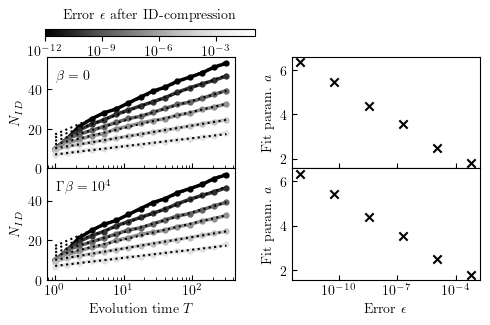

In [293]:
filename_ID = f'../data/paper/paper_ID_Lambda100000_opt_onlypos.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)

#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})
#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "explicit_poles"]

#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

errors_discretization = data_h5_ID["eps"]
m_vals = data_h5_ID["m"] #factor 2 for positive and negative frequencies
n_vals = data_h5_ID["n"] #factor 2 for positive and negative frequencies
h_vals = data_h5_ID["h"]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_modes_finegrid = (m_vals + n_vals) + 1 + nbr_explicit_poles / 2 #factor 1/2 because here we consider only positive frequencies

print(f"Errors Discretization: {errors_discretization}")
print(f"Errors ID: {errors_ID}")


# Set global fontsize using rcParams

cmap_grays = plt.get_cmap("Greys_r")
# Configuration and data preparation
nbr_interpolations = 7

error_min_ID = np.min(errors_ID[errors_ID > 0])

error_grid_ID = np.logspace(np.log10(np.max([error_min_ID,1.e-12])), np.log10(np.max(errors_ID)), nbr_interpolations)


fig, axs = plt.subplots(kernel_dims_ID[2], 2, figsize=(5, 3.2), sharex='col')
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

ID_ranks_interp = np.zeros((len(error_grid_ID), kernel_dims_ID[1]))

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Use logarithmic normalization
norm_ID = mcolors.LogNorm(vmin=error_grid_ID[0], vmax=3*error_grid_ID[-1])


        
# Interpolation and plotting ID data
for b in range (kernel_dims_ID[2]):#loop over beta values

    fitting_params_a_ID = np.zeros((len(error_grid_ID),))

    for tau in range (kernel_dims_ID[1]):#loop over final time values, N_max
        mask_ID = errors_ID[:,tau,b] > 0. # Mask to filter values clearly above machine precision
        ID_RANKS_INTERP = DataInterp(errors_ID[mask_ID, tau,b], ID_ranks[mask_ID, tau,b])
        ID_ranks_interp[:, tau] = ID_RANKS_INTERP.interp(error_grid_ID, x_scale='log')    
      

    
    for eps_iter in range(len(error_grid_ID)):
        #plot only nonzero values
        mask_ID = ID_ranks_interp[eps_iter, :] > 0.
        error_ID = error_grid_ID[eps_iter]

        axs[b,0].plot(t_data[mask_ID], ID_ranks_interp[eps_iter, mask_ID], marker="o", linestyle="-", markersize=3.5, linewidth = 2.5, color=cmap_grays(norm_ID(error_ID)))    
        #fit logarithmic curves
        if sum(mask_ID) > 1:
            params_ID = fit_logarithmic(t_data[mask_ID][2:], ID_ranks_interp[eps_iter, mask_ID][2:])
            fitting_params_a_ID[eps_iter] = params_ID[0]

            #plot fitting function
            axs[b,0].plot(t_data[mask_ID], log_func(t_data[mask_ID], *params_ID), color="black", linestyle="dotted", linewidth=1.5)
            #plot fitting parameters
            axs[b,1].scatter(error_ID, params_ID[0], marker="x",  color=cmap_grays(1))
       
   
    axs[b,0].set_ylabel(r"$N_{ID}$")
    axs[b,1].set_ylabel("Fit param. " + r'$a$')
  

    axs[b,0].set_xscale('log')
    axs[b,1].set_xscale('log')

    axs[b,0].set_ylim(bottom=0)


#for text inset, choose background color white
axs[0,0].text(0.05, 0.8, r"$\beta = 0$", transform=axs[0,0].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,0].text(0.05, 0.8, r"$\Gamma\beta = 10^4$", transform=axs[1,0].transAxes,backgroundcolor=(1, 1, 1, 0.9))
# Setting labels and legend
axs[-1,0].set_xlabel("Evolution time " + r'$T$')
axs[-1,1].set_xlabel("Error " + r'$\epsilon$')


# Add a colorbar for the blues above the figure
cax_grays = fig.add_axes([0.1, 0.92, 0.42, 0.02])
sm_grays = cm.ScalarMappable(cmap=cmap_grays, norm=norm_ID)
sm_grays.set_array([])
cbar_grays = fig.colorbar(sm_grays, cax=cax_grays, orientation='horizontal')
cbar_grays.set_label("Error " + r'$\epsilon$' + " after ID-compression", labelpad=-35, fontsize='medium')



#move all ticks into plotting area
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

plt.tight_layout(rect=[0, 0, 1, 0.9])  # Adjust the layout to make space for the colorbars

#move lower plots closer to upper plots, such that the upper edge of the lower plots zouces with the lower edge of the upper plots. do not use subplots_adjust
fig.subplots_adjust(hspace=0.0, wspace=.3)

# Save the figure as a PDF
plt.savefig('../plots/paper/flatband_ID_time_dependence_Lambda100000_pos.pdf', format='pdf', bbox_inches='tight')


In [61]:
filename_ID = f'../data/paper/paper_ID_Lambda50_opt_low_temp.h5'
filename_AAA = f'../data/paper/paper_AAA_Lambda50_lowtemp.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)

#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys = ["eps", "m", "n", "h", "N_max", "beta", "delta_t", "ID_rank","ID_error_reconstr_vs_cont", "only_positive_particle", "additional_poles", "explicit_poles"]

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
#order of indices: h_vals, N_maxs, beta

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)

nbr_additional_poles = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_maxs = data_h5_ID["N_max"]
betas = data_h5_ID["beta"]
delta_t_vals = data_h5_ID["delta_t"]
ID_ranks = data_h5_ID["ID_rank"]
errors_ID = data_h5_ID["ID_error_reconstr_vs_cont"]


#Extract the relevant data for plotting from hdf5 file. Assemble it conveniently into multidimensional arrays.
keys_sc = ["beta", "N_max", "delta_t", "AAA_error_reconstr_vs_cont","nbr_poles_upper", "tol", "Z", "F_particle", "ID_rank_particle", "ID_rank_hole"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc = data_h5_AAA_sc["N_max"]
betas_sc = data_h5_AAA_sc["beta"]
delta_t_vals_sc = data_h5_AAA_sc["delta_t"]
tol_vals_sc = data_h5_AAA_sc["tol"]
Z_vals_sc = data_h5_AAA_sc["Z"]
F_vals_sc = data_h5_AAA_sc["F_particle"]


#read out the same data from another set of two files
filename_ID = f'../data/paper/paper_ID_Lambda1_opt_low_temp.h5'
filename_AAA = f'../data/paper/paper_AAA_Lambda1_lowtemp.h5'
#Create instance of Hdf5Kernel
h5_kernel_ID = Hdf5Kernel(filename=filename_ID)
h5_kernel_AAA = Hdf5Kernel(filename=filename_AAA)

kernel_dims_ID, data_h5_ID = h5_kernel_ID.read_scalars_to_array(keys=keys)


nbr_additional_poles2 = np.array(data_h5_ID["additional_poles"]).shape[1]
nbr_explicit_poles2 = np.array(data_h5_ID["explicit_poles"]).shape[1]
N_maxs2 = data_h5_ID["N_max"]
betas2 = data_h5_ID["beta"]
delta_t_vals2 = data_h5_ID["delta_t"]
ID_ranks2 = data_h5_ID["ID_rank"]
errors_ID2 = data_h5_ID["ID_error_reconstr_vs_cont"]

kernel_dims_AAA_sc, data_h5_AAA_sc = h5_kernel_AAA.read_scalars_to_array(keys=keys_sc)

errors_AAA_sc2 = data_h5_AAA_sc["AAA_error_reconstr_vs_cont"]
nbr_poles_upper_sc2 = data_h5_AAA_sc["nbr_poles_upper"]
AAA_ID_rank_particle2 = data_h5_AAA_sc["ID_rank_particle"]
AAA_ID_rank_holes2 = data_h5_AAA_sc["ID_rank_hole"]
N_maxs_sc2 = data_h5_AAA_sc["N_max"]
betas_sc2 = data_h5_AAA_sc["beta"]
delta_t_vals_sc2 = data_h5_AAA_sc["delta_t"]
tol_vals_sc2 = data_h5_AAA_sc["tol"]
Z_vals_sc2 = data_h5_AAA_sc["Z"]
F_vals_sc2 = data_h5_AAA_sc["F_particle"]


#make sure the same time steps, final times and betas are used for both methods
assert np.allclose(betas[0], betas_sc[0])
assert np.allclose(N_maxs[0], N_maxs_sc[0])
assert np.allclose(delta_t_vals[0], delta_t_vals_sc[0])

t_data = np.array([np.max(N_maxs[:,tau,:] * delta_t_vals[:,tau,:]) for tau in range (kernel_dims_ID[1])])

# Set global fontsize using rcParams
from itertools import cycle

# Function to generate linestyles cycler
def generate_linestyles_cycler(n):
    predefined_linestyles = ['-','--', '-.', ':']
    return cycle(predefined_linestyles[:n])

linestyles = generate_linestyles_cycler(kernel_dims_ID[1])
linecycler = cycle(linestyles)




<>:82: SyntaxWarning: invalid escape sequence '\G'
<>:82: SyntaxWarning: invalid escape sequence '\G'
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_98598/1352407981.py:82: SyntaxWarning: invalid escape sequence '\G'
  """for col in range(2):


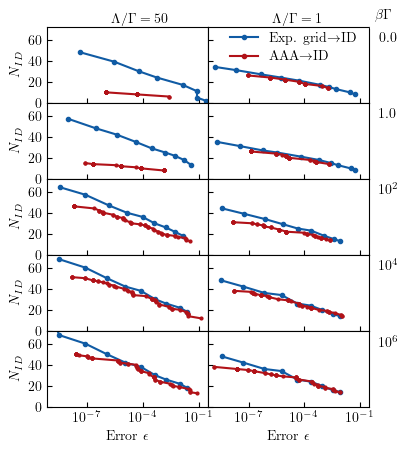

In [132]:

fig, axs = plt.subplots(5, 2, figsize=(4, 5), sharey=True, sharex=True)
#Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})


norm_times = mcolors.LogNorm(vmin=0.1 * np.min(t_data[t_data > 0]), vmax=4*np.max(t_data))

for b in range(kernel_dims_ID[2]):
    #reset the line cyler to start fresh for each beta
    linecycler = generate_linestyles_cycler(4)
    #for tau in np.arange(kernel_dims_ID[1]-1,0,-4)[::-1]:
    for tau in np.arange(kernel_dims_ID[1]-1,kernel_dims_ID[1]-2,-1)[::-1]:

        err_ID = []
        ID_modes = []
        err_ID2 = []
        ID_modes2 = []
        
        for iter in range (errors_ID.shape[0]):
            err_ID.append(errors_ID[iter, tau, b])
            err_ID2.append(errors_ID2[iter, tau, b])
            ID_modes.append(ID_ranks[iter, tau, b])
            ID_modes2.append(ID_ranks2[iter, tau, b])

        #convert arrays to numpy arrays
        err_ID = np.array(err_ID)
        ID_modes = np.array(ID_modes)
        err_ID2 = np.array(err_ID2)
        ID_modes2 = np.array(ID_modes2)

        linestyle = next(linecycler)
        mask_ID = err_ID > 1.e-9
        mask_ID2 = err_ID2 > 1.e-9

        line_ID, = axs[b,0].plot(err_ID[mask_ID], ID_modes[mask_ID], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])))
        line_ID2, = axs[b,1].plot(err_ID2[mask_ID2], ID_modes2[mask_ID2], marker="o", linestyle=linestyle, markersize=3, 
                               color=cmap_blues(norm_times(t_data[tau])))


        err_AAA_sc = []
        nbr_poles_sc = []
        err_AAA_sc2 = []
        nbr_poles_sc2 = []
       
        for tol_iter in range(len(tol_vals_sc[:, tau, b])):
            err_AAA_sc.append(errors_AAA_sc[tol_iter, tau, b])
            nbr_poles_sc.append(AAA_ID_rank_particle[tol_iter, tau, b] + AAA_ID_rank_holes[tol_iter, tau, b])
            err_AAA_sc2.append(errors_AAA_sc2[tol_iter, tau, b])
            nbr_poles_sc2.append(AAA_ID_rank_particle2[tol_iter, tau, b] + AAA_ID_rank_holes2[tol_iter, tau, b])
        
        err_AAA_sc = np.array(err_AAA_sc)
        nbr_poles_sc = np.array(nbr_poles_sc)
        err_AAA_sc2 = np.array(err_AAA_sc2)
        nbr_poles_sc2 = np.array(nbr_poles_sc2)

        mask_AAA = err_AAA_sc > 1.e-8
        mask_AAA2 = err_AAA_sc > 2.e-8
        
        line_AAA, = axs[b,0].plot(err_AAA_sc[mask_AAA], nbr_poles_sc[mask_AAA], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])))
        
        line_AAA2, = axs[b,1].plot(err_AAA_sc2[mask_AAA2], nbr_poles_sc2[mask_AAA2], marker="o", linestyle=linestyle, markersize=2, 
                                color=cmap_reds(norm_times(t_data[tau])))
     


    axs[b,0].set_ylabel(r"$N_{ID}$")
    axs[b,0].set_xscale("log")
    axs[b,0].set_xlim(right=3.e-1)
    axs[b,0].set_ylim(bottom=0, top = 72)


    axs[b,1].set_xscale("log")
    axs[b,1].set_xlim(right=3.e-1)
    axs[b,1].set_ylim(bottom=0, top = 72)


axs[-1,0].set_xlabel("Error " + r"$\epsilon$")
axs[-1,1].set_xlabel("Error " + r"$\epsilon$")

"""for col in range(2):
    
    #for text inset, choose background color white
    axs[0,col].text(0.75, 0.75, r"$\beta = 0$", transform=axs[0,0].transAxes, backgroundcolor='white')
    axs[1,col].text(0.75, 0.75, r"$\Gamma\beta  = 1$", transform=axs[1,0].transAxes, backgroundcolor='white')
    axs[2,col].text(0.75, 0.75, r"$\Gamma\beta  = 100$", transform=axs[2,0].transAxes, backgroundcolor='white')
    axs[3,col].text(0.75, 0.75, r"$\Gamma\beta  = 10^4$", transform=axs[3,0].transAxes, backgroundcolor='white')
    axs[4,col].text(0.75, 0.75, r"$\Gamma\beta  = 10^6$", transform=axs[4,0].transAxes, backgroundcolor='white')
"""


# Add a single legend above the entire figure
from matplotlib.legend import Legend


# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])

#for first row, add a small black arrow to point at one curve. Annotate the arrow with text "blabla"
#axs[0,0].annotate("curves superimposed", xy=(0.001, 6), xytext=(0.4, 0.55), textcoords='axes fraction', arrowprops=dict(facecolor='black', arrowstyle='->'))


#write column labels
axs[0,0].text(0.4, 1.05, r'$\Lambda/\Gamma = 50$', transform=axs[0,0].transAxes)
axs[0,1].text(0.4, 1.05, r'$\Lambda/\Gamma = 1$', transform=axs[0,1].transAxes)


"""
# Adjust layout to make space for the legends
plt.tight_layout(rect=[0, 0, 1, 0.9])
#write row labels for color bars
fig.text(0.745, .915, "AAA"+r'$\to$' + "ID")
fig.text(0.745, .88, "Exp. grid"+r'$\to$' + "ID")
# Add a colorbar for the reds above the figure
cax_reds = fig.add_axes([0.13, .915, 0.6, 0.02])
sm_reds = cm.ScalarMappable(cmap=cmap_reds, norm=norm_times)
sm_reds.set_array([])
#horizontal colorbar with tick labes on top
cbar_reds = fig.colorbar(sm_reds, cax=cax_reds, orientation='horizontal')
cbar_reds.set_label("Evolution time " + r'$T$', labelpad=5, fontsize='medium')
# Place ticks inside the red colorbar and only on top of the colorbar, not on bottom
cbar_reds.ax.tick_params(axis='x', which='both', direction='in', top = True, bottom = False)
# Place tick labels above the color bar
cbar_reds.ax.xaxis.set_ticks_position('top')
cbar_reds.ax.xaxis.set_label_position('top')


# Add a colorbar for the blues above the figure, but without a label
cax_blues = fig.add_axes([0.13, 0.883, 0.6, 0.02])
sm_blues = cm.ScalarMappable(cmap=cmap_blues, norm=norm_times)
sm_blues.set_array([])
cbar_blues = fig.colorbar(sm_blues, cax=cax_blues, orientation='horizontal')
# Place ticks inside the blue colorbar
cbar_blues.ax.set_xticklabels([])
cbar_blues.ax.tick_params(axis='x', which='both', direction='in', top = True, bottom = False)
# Ensure the colorbars are aligned and share the same title
cbar_reds.ax.xaxis.set_label_position('top')"""

#add custom legend for each color above figure
from matplotlib.lines import Line2D
legend_elements = [Line2D([0], [0], color=cmap_blues(norm_times(t_data[-1])), linestyle='-', label='Exp. grid'+r"$\to$" + "ID", marker='o', markersize=3),
                   Line2D([0], [0], color=cmap_reds(norm_times(t_data[-1])), linestyle='-', label='AAA'+r"$\to$" + "ID", marker='o', markersize=3)]
#create legend in subplot [0,1]
axs[0,1].legend(handles=legend_elements, loc='upper right', bbox_to_anchor=(1.0, 1.1), frameon=False)


#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0.0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$1.0$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[2,1].text(1.06, 0.8, r"$10^2$", transform=axs[2,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[3,-1].text(1.06, 0.8, r"$10^4$", transform=axs[3,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[4,1].text(1.06, 0.8, r"$10^6$", transform=axs[4,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#for right column, move y-axis ticks and labels to the right
#for ax in axs[:,1]:
#    ax.yaxis.set_label_position("right")
#    ax.yaxis.set_ticks_position("right")

#no tick labels for right column
for ax in axs[:,1]:
    ax.yaxis.set_tick_params(labelright=False)

#for left column, set ticks in intervals of 20
for ax in axs[:,0]:
    ax.yaxis.set_major_locator(plt.MultipleLocator(20))


    
#move lower plots closer to upper plots
fig.subplots_adjust(hspace=0.0, wspace=0.0)

# Save the figure as a PDF
plt.savefig('../plots/paper/paper_flatband_comparison_Lambda=50_and_1_pos.pdf', format='pdf', bbox_inches='tight')





<>:112: SyntaxWarning: invalid escape sequence '\L'
<>:112: SyntaxWarning: invalid escape sequence '\L'
/var/folders/cg/_38xw63s1fg5wbmw91yk0qzr0000gn/T/ipykernel_98598/2655991726.py:112: SyntaxWarning: invalid escape sequence '\L'
  """axs[0,0].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[0,0].transAxes, color = 'white')


AAA 0.2771967698942152 4.454034562281046
ID 0.2632040992879954 2.132318703543853
AAA 0.37574252236858635 4.352081737381471
ID 0.3811273791304595 4.071252098081094
global_min 0.1223550819111247
global_max 8.239222879444256
global_min 0.1
global_max 10.0


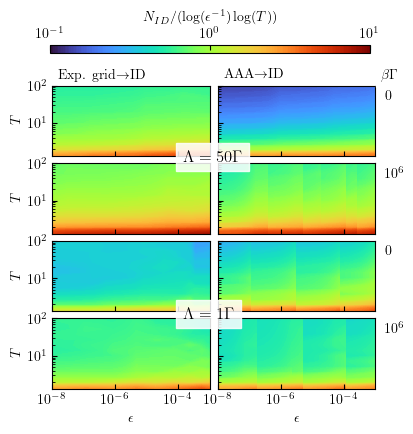

In [128]:
#2D plot that shows N_ID / (log(eps^-1) log(T))

cmap_blues = plt.get_cmap("Blues")
cmap_reds = plt.get_cmap("Reds")
#order of indices: h_vals, N_maxs, beta

# Set plot parameters
plt.rcParams.update({"text.usetex": True, "font.family": "serif", "font.size": 10})

fig, axs = plt.subplots(4,2, figsize=(4, 4.2), sharex=True, sharey=True)


global_min = float('inf')
global_max = float('-inf')

# Calculate global min and max
for b, b_idx in enumerate([0, 4]):
    # ID data
    norm_ID = np.log(1/errors_ID[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks[:,1:,b_idx] / norm_ID
    global_min = min(global_min, nbr_modes_rescaled_ID.min())
    global_max = max(global_max, nbr_modes_rescaled_ID.max())

    # AAA data
    norm_AAA = np.log(1/errors_AAA_sc[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle[:,1:,b_idx] + AAA_ID_rank_holes[:,1:,b_idx]) / norm_AAA
    global_min = min(global_min, nbr_modes_rescaled_AAA.min())
    global_max = max(global_max, nbr_modes_rescaled_AAA.max())

    # ID data
    norm_ID = np.log(1/errors_ID2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks2[:,1:,b_idx] / norm_ID
    global_min = min(global_min, nbr_modes_rescaled_ID.min())
    global_max = max(global_max, nbr_modes_rescaled_ID.max())

    # AAA data
    norm_AAA = np.log(1/errors_AAA_sc2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle2[:,1:,b_idx] + AAA_ID_rank_holes2[:,1:,b_idx]) / norm_AAA
    global_min = min(global_min, nbr_modes_rescaled_AAA.min())
    global_max = max(global_max, nbr_modes_rescaled_AAA.max())

    print("AAA", nbr_modes_rescaled_AAA.min(), nbr_modes_rescaled_AAA.max())
    print("ID", nbr_modes_rescaled_ID.min(), nbr_modes_rescaled_ID.max())

print("global_min", global_min)
print("global_max", global_max)

#round to the nearest power of 10
global_min = 10**np.floor(np.log10(global_min))
global_max = 10**np.ceil(np.log10(global_max))
print("global_min", global_min)
print("global_max", global_max)
#normalize the data on a log scale
from matplotlib.colors import LogNorm
norm = LogNorm(vmin=global_min, vmax=global_max)
# Precompute levels on a log scale
levels = np.logspace(np.log10(global_min), np.log10(global_max), 200)

#from matplotlib.colors import Normalize
#norm = Normalize(vmin=global_min, vmax=global_max)
# Precompute levels
#levels = np.linspace(global_min, global_max, 200)

for b, b_idx in enumerate([0, 4]):
    #Lambda = 50
    # ID data
    X, Y = np.meshgrid(errors_ID[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_ID = np.log(1/errors_ID[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks[:,1:,b_idx] / norm_ID 

    contour_ID = axs[b,0].contourf(X, Y, nbr_modes_rescaled_ID.T, cmap="turbo", levels=levels, vmin=global_min, vmax=global_max, norm=norm)
    axs[b,0].set_ylabel(r"$T$")
    axs[b,0].set_xscale("log")
    axs[b,0].set_yscale("log")
    axs[b,0].set_xlim(left=1.e-10, right=1.e-3)

    # AAA data
    X, Y = np.meshgrid(errors_AAA_sc[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_AAA = np.log(1/errors_AAA_sc[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle[:,1:,b_idx] + AAA_ID_rank_holes[:,1:,b_idx]) / norm_AAA 

    contour_AAA = axs[b,1].contourf(X, Y, nbr_modes_rescaled_AAA.T, cmap="turbo", levels=levels, norm=norm)
    axs[b,1].set_xscale("log")
    axs[b,1].set_yscale("log")
    axs[b,1].set_xlim(left=1.e-8, right=1.e-3)

    #Lambda = 1
    # ID data
    X, Y = np.meshgrid(errors_ID2[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_ID = np.log(1/errors_ID2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_ID = ID_ranks2[:,1:,b_idx] / norm_ID 

    contour_ID = axs[b+2,0].contourf(X, Y, nbr_modes_rescaled_ID.T, cmap="turbo", levels=levels, vmin=global_min, vmax=global_max, norm=norm)
    axs[b+2,0].set_ylabel(r"$T$")
    axs[b+2,0].set_xscale("log")
    axs[b+2,0].set_yscale("log")
    axs[b+2,0].set_xlim(left=1.e-10, right=1.e-3)

    # AAA data
    X, Y = np.meshgrid(errors_AAA_sc2[:,0,b_idx], N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    norm_AAA = np.log(1/errors_AAA_sc2[:,1:,b_idx][:,np.newaxis]) * np.log(N_maxs[0,1:,b_idx] * delta_t_vals[0,1:,b_idx])
    nbr_modes_rescaled_AAA = (AAA_ID_rank_particle2[:,1:,b_idx] + AAA_ID_rank_holes2[:,1:,b_idx]) / norm_AAA 

    contour_AAA = axs[b+2,1].contourf(X, Y, nbr_modes_rescaled_AAA.T, cmap="turbo", levels=levels, norm=norm)
    axs[b+2,1].set_xscale("log")
    axs[b+2,1].set_yscale("log")
    axs[b+2,1].set_xlim(left=1.e-8, right=1.e-3)

axs[-1,0].set_xlabel(r"$\epsilon$")
axs[-1,1].set_xlabel(r"$\epsilon$")

"""axs[0,0].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[0,0].transAxes, color = 'white')
axs[1,0].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[1,0].transAxes, color = 'white')
axs[0,1].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[0,1].transAxes, color = 'white')
axs[1,1].text(0.6,0.8,r"$\Lambda = 50\Gamma$", transform=axs[1,1].transAxes, color = 'white')

axs[2,0].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[2,0].transAxes, color = 'white')
axs[3,0].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[3,0].transAxes, color = 'white')
axs[2,1].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[2,1].transAxes, color = 'white')
axs[3,1].text(0.6,0.8,r"$\Lambda = 1\Gamma$", transform=axs[3,1].transAxes, color = 'white')"""
#transparent white background color for text
fig.text(0.83,-.07,r"$\Lambda = 50\Gamma$", transform=axs[0,0].transAxes, color = 'black', backgroundcolor=(1, 1, 1, 0.85), fontsize='large')
fig.text(0.83,-2.3,r"$\Lambda = 1\Gamma$", transform=axs[0,0].transAxes, color = 'black', backgroundcolor=(1, 1, 1, 0.85), fontsize='large')

plt.tight_layout(rect=[0, 0, 1, 0.9])
cax_ID = fig.add_axes([0.15, 0.93, 0.8, 0.02])

fig.subplots_adjust(hspace=0.1, wspace=0.05)

cbar_ID = fig.colorbar(contour_AAA, cax=cax_ID, orientation='horizontal')

#print range of values
cbar_ID.set_ticks([.1, 1, 10])
#for the colobar ranging from 0.1 to 10, set a tick at every integer value
#cbar_ID.set_ticks([0, 1, 10])






cbar_ID.ax.xaxis.set_ticks_position('top')
cbar_ID.ax.xaxis.set_label_position('top')
cbar_ID.ax.tick_params(axis='x', which='both', direction='in', top=True, bottom=False)
cbar_ID.set_label(r"$N_{ID} / (\log(\epsilon^{-1}) \log(T))$", labelpad=5, fontsize='medium')


#move all ticks into plot area:
for ax in axs.flat:
    ax.xaxis.set_tick_params(which='both', direction='in')
    ax.yaxis.set_tick_params(which='both', direction='in')

#label for each column
fig.text(0.28, 0.87, "Exp. grid"+r'$\to$' + "ID", ha='center')
fig.text(0.66, 0.87, "AAA"+r'$\to$' + "ID", ha='center')

#write the temperature values into plots
#for text inset, choose background color white
axs[0,-1].text(1.04, 1.1, r"$\beta \Gamma$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[0,-1].text(1.06, 0.8, r"$0$", transform=axs[0,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[1,-1].text(1.06, 0.8, r"$10^6$", transform=axs[1,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[2,1].text(1.06, 0.8, r"$0$", transform=axs[2,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))
axs[3,-1].text(1.06, 0.8, r"$10^6$", transform=axs[3,-1].transAxes, backgroundcolor=(1, 1, 1, 0.9))


#second figure for Lambda=1
#save the figure as a PDF
plt.savefig('../plots/paper/complexity_flatband_Lambda=50vs1.pdf', format='pdf', bbox_inches='tight')